In [1]:
import torch
import matplotlib.pyplot as plt
import glob
import os

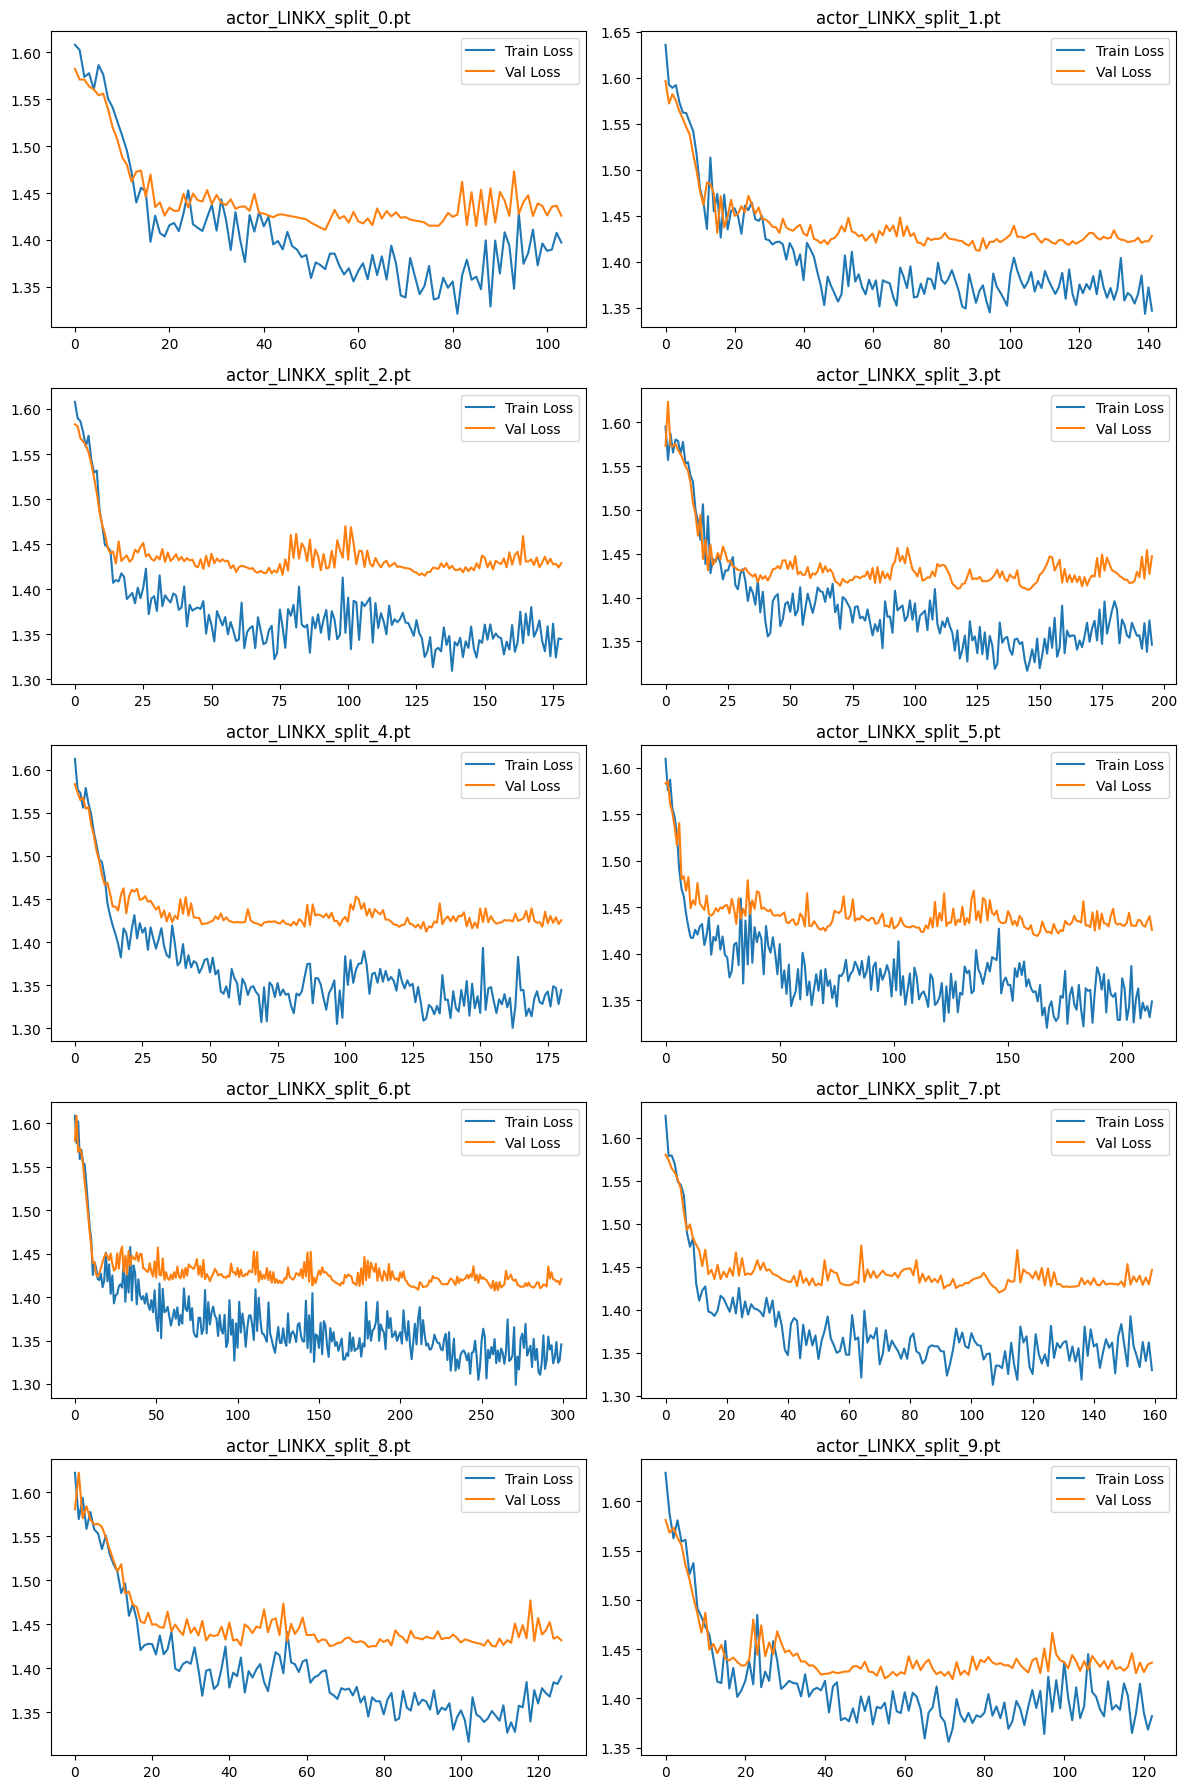

In [5]:
dataset_name = "actor"
model_name = "LINKX"

files = sorted(glob.glob(f"results/{dataset_name}_{model_name}_*.pt"))

n = len(files)  # should be 9

rows = 5
cols = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 18))

# flatten for easier indexing
axes = axes.flatten()

for i, file in enumerate(files):
    data = torch.load(file)

    train_loss = data["train_loss"]
    val_loss = data["val_loss"]

    name = os.path.basename(file)

    ax = axes[i]

    ax.plot(train_loss, label="Train Loss")
    ax.plot(val_loss, label="Val Loss")

    ax.set_title(name)
    ax.legend()

# ---- remove the unused subplot (bottom-left) ----
# index 8 is last used, index 9 is extra
for j in range(n, rows * cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()